# 04 — Visualize

**Consumes** `data/processed/admission_long.parquet` (from `nb/01_clean`) and
`data/processed/exam_subject_stats.csv` + `tscore_coefficients.csv`.

**Emits** eight figures to `reports/figures/`.

**Concludes** the raw min-score series flatters Chula. Once each program is
ranked inside its own year's national distribution, **every** faculty's move
is more negative than its raw move, and two faculties flip sign outright:
จิตวิทยา and นิติศาสตร์ look like they got harder in raw points while actually
slipping against the national field.

All styling comes from `src/viz.py` — one palette, one font setup, no
per-notebook restyling.

## 0. Thai font — verified, not assumed

matplotlib falls back to DejaVu Sans and draws a box per Thai glyph without
raising anything. On this machine the trap is live: **`Sarabun` is listed by
the font manager but `findfont` returns DejaVu**. So the font is never trusted
by name. `viz.setup()` does two checks:

1. **static** — reads the candidate font file's own charmap and confirms it
   contains every Thai codepoint we draw;
2. **dynamic** — renders a probe string and escalates matplotlib's
   `Glyph N missing from font` warning to an error.

`TH Sarabun New` wins, with `DejaVu Sans` behind it in the family stack to
supply symbols (it has no `→`).

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd

from src.load import load_all, chula
from src.normalize import with_percentile_rank
from src import viz

font = viz.setup()          # raises if Thai would render as tofu
print("font:", font, "|", viz._font_path(font).name)

font: TH Sarabun New | THSarabunNew_761872542.ttf


In [2]:
# Prove the detector works, rather than trusting a silent pass.
try:
    viz.verify_thai_rendering("DejaVu Sans")
    print("PROBLEM: tofu went undetected")
except RuntimeError as e:
    print("tofu correctly rejected:", str(e).splitlines()[1].strip()[:70])

tofu correctly rejected: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu San


In [3]:
df = load_all()
ch = chula(df)
valid = ch[ch["passed"] > 0]
print(f"{len(df):,} national rows · {len(ch)} Chula rows · {len(valid)} with admits")

19,437 national rows · 540 Chula rows · 483 with admits


## 1 + 2. Faculty small-multiples — raw, and the same grid normalized

Fourteen panels of median คะแนนต่ำสุด and คะแนนสูงสุด against the national
median, then the identical grid on **percentile rank within each year's
national distribution**. Panels are in the same order in both blocks, so any
cell can be read top-to-bottom.

The percentile track is the scale-free one: it is unaffected by exam-difficulty
drift, because it asks where a program sits relative to everything else in
Thailand that same year rather than what number it scored.

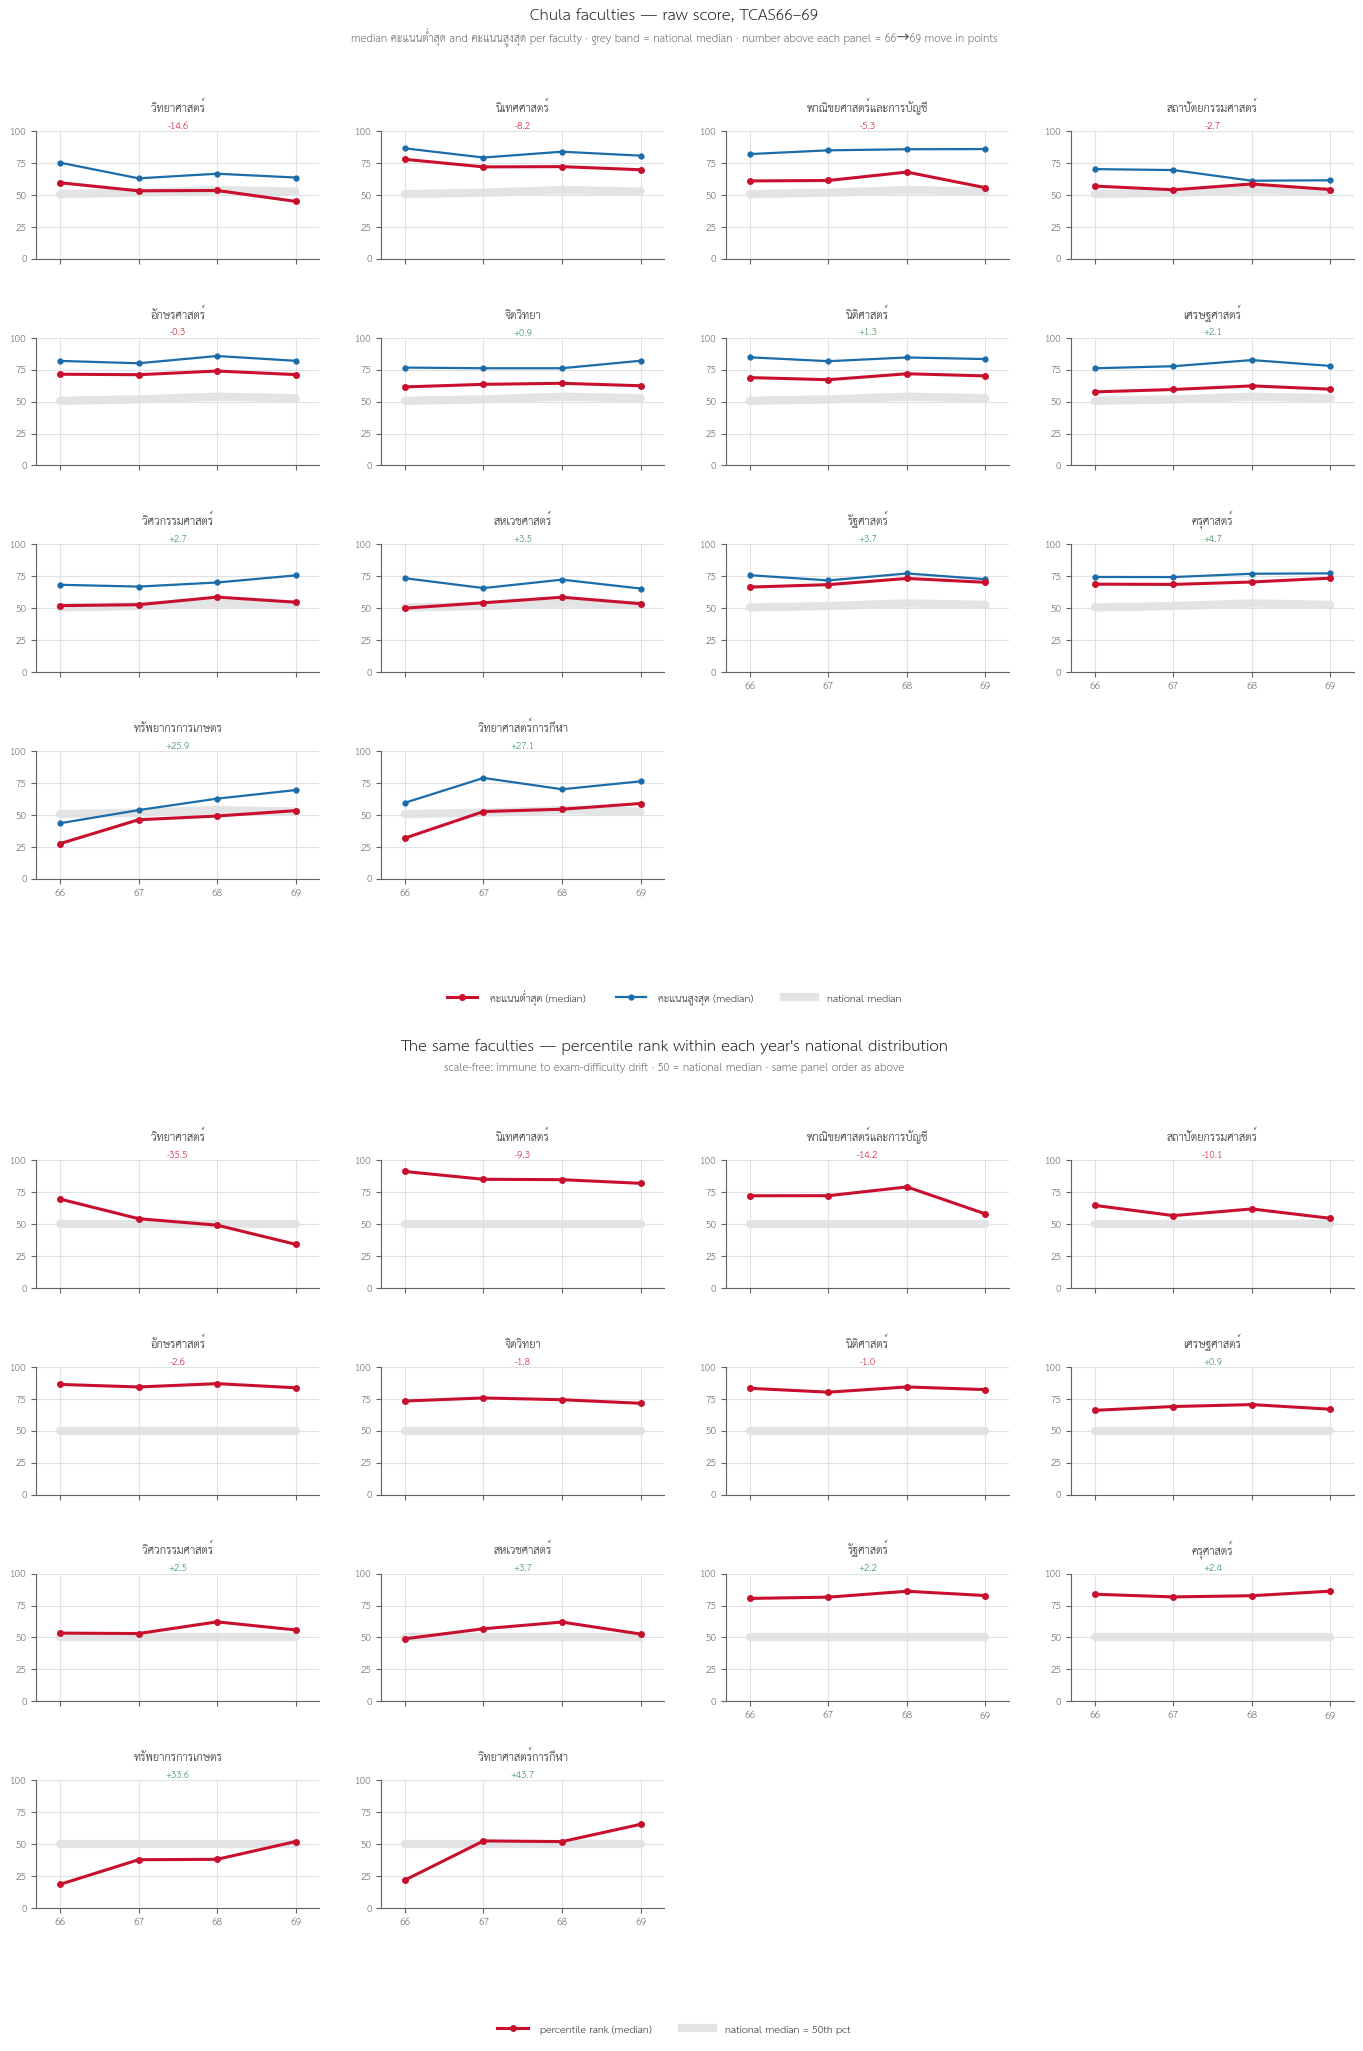

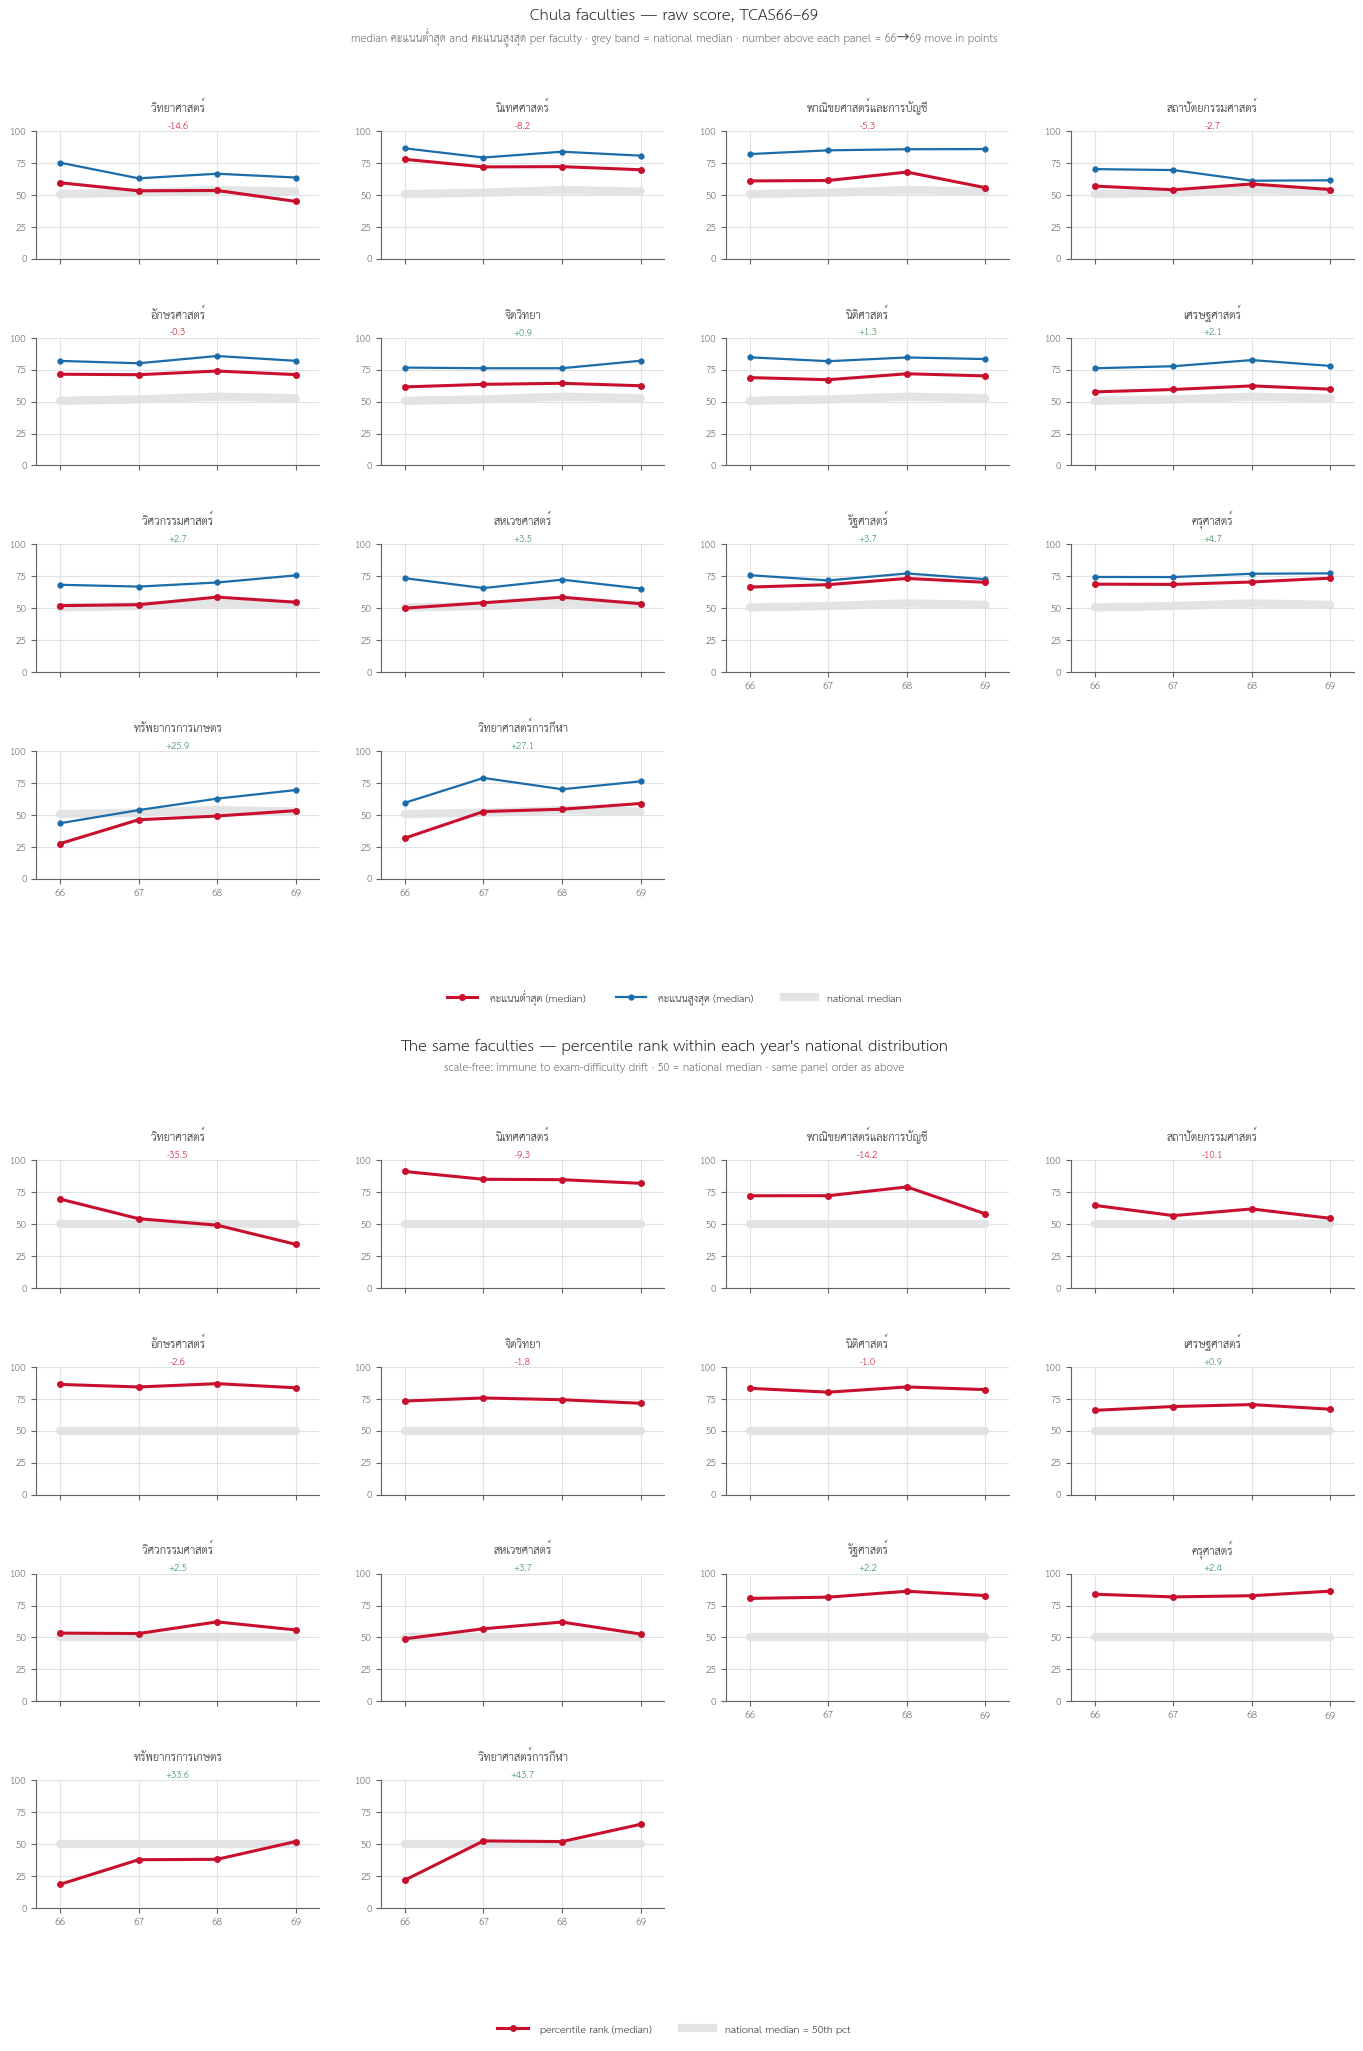

In [4]:
fig = viz.fig_faculty_raw_vs_normalized(df)
viz.save(fig, "01_faculty_raw_vs_normalized")
fig

### The divergence, as numbers

Raw and normalized disagree because the national median rose faster than
Chula's floors — 50.64 → 52.66 over the four years. A Chula program can gain
raw points and still lose ground.

In [5]:
pct = with_percentile_rank(df)
v = chula(pct)[chula(pct)["passed"] > 0]
raw_med = v.pivot_table(index="faculty", columns="year", values="min_score", aggfunc="median")
pct_med = v.pivot_table(index="faculty", columns="year", values="pct_rank", aggfunc="median")

cmp = pd.DataFrame({"raw Δ": (raw_med[69] - raw_med[66]).round(1),
                    "pct Δ": (pct_med[69] - pct_med[66]).round(1)})
cmp["divergence"] = (cmp["pct Δ"] - cmp["raw Δ"]).round(1)
cmp["sign flip"] = ((cmp["raw Δ"] > 0) & (cmp["pct Δ"] < 0)) | \
                   ((cmp["raw Δ"] < 0) & (cmp["pct Δ"] > 0))
cmp.sort_values("raw Δ")

,raw Δ,pct Δ,divergence,sign flip
faculty,,,,
คณะวิทยาศาสตร์,-14.6,-35.5,-20.9,False
คณะนิเทศศาสตร์,-8.2,-9.3,-1.1,False
คณะพาณิชยศาสตร์และการบัญชี,-5.3,-14.2,-8.9,False
คณะสถาปัตยกรรมศาสตร์,-2.7,-10.1,-7.4,False
คณะอักษรศาสตร์,-0.3,-2.6,-2.3,False
คณะจิตวิทยา,0.9,-1.8,-2.7,True
คณะนิติศาสตร์,1.3,-1.0,-2.3,True
คณะเศรษฐศาสตร์,2.1,0.9,-1.2,False
คณะวิศวกรรมศาสตร์,2.7,2.5,-0.2,False


Two readings worth stating plainly:

- **คณะวิทยาศาสตร์ is the big story.** −14.6 raw points understates it; on
  percentile rank it falls **−35.5 points**, from the 70th percentile to the
  35th. It is the only Chula faculty to cross the national median.
- **จิตวิทยา (+0.9 raw, −1.8 pct) and นิติศาสตร์ (+1.3 raw, −1.0 pct) flip
  sign.** Raw points say they got harder; against the national field they
  slipped. Anyone reading the raw series alone would draw the wrong conclusion
  for these two.

Only สหเวชศาสตร์ and the two undersubscribed outliers improve by more on the
normalized track than the raw one.

## 3. Major-level detail inside a faculty

`plot_faculty()` draws every program in one faculty. Programs sharing a long
degree prefix have it stripped so the distinguishing part of the name survives,
and programs that share a name across two codes (regular vs international
intake) are separated by `รายละเอียด`.

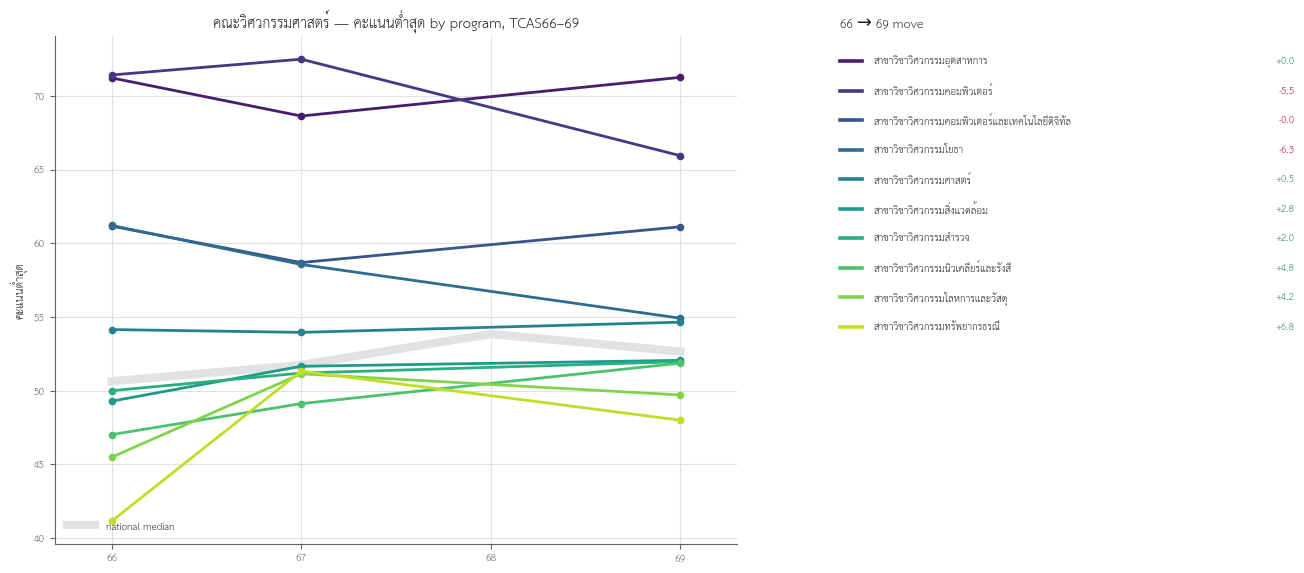

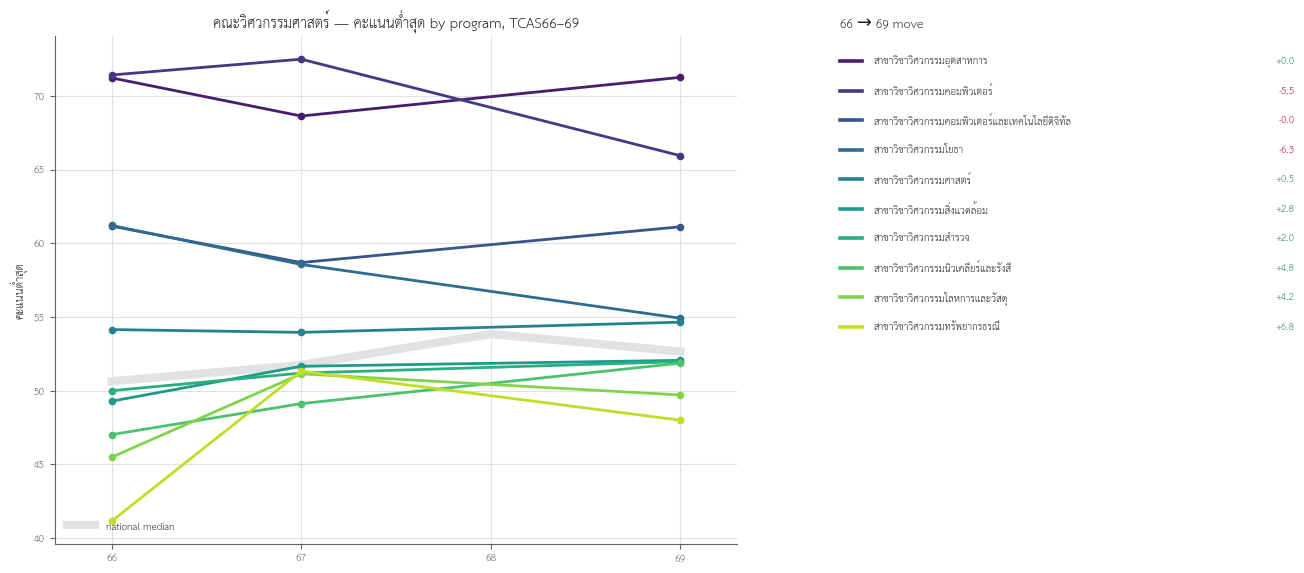

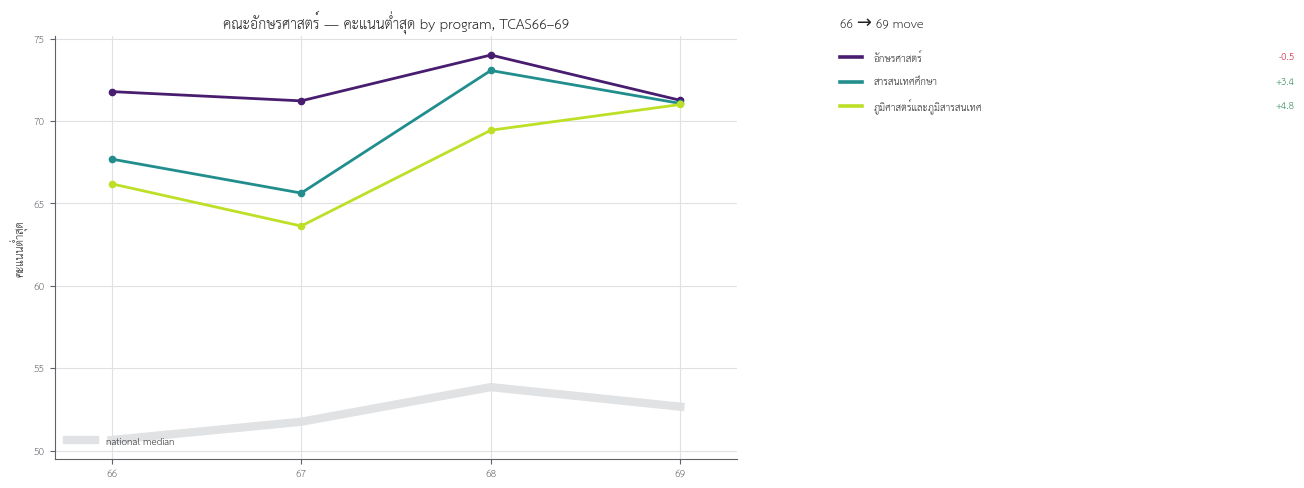

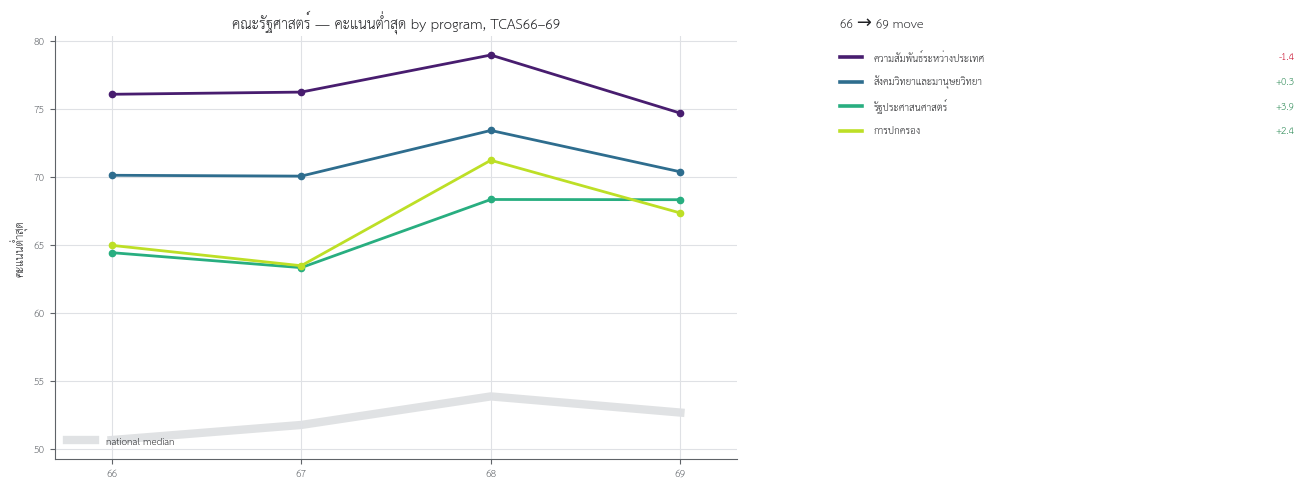

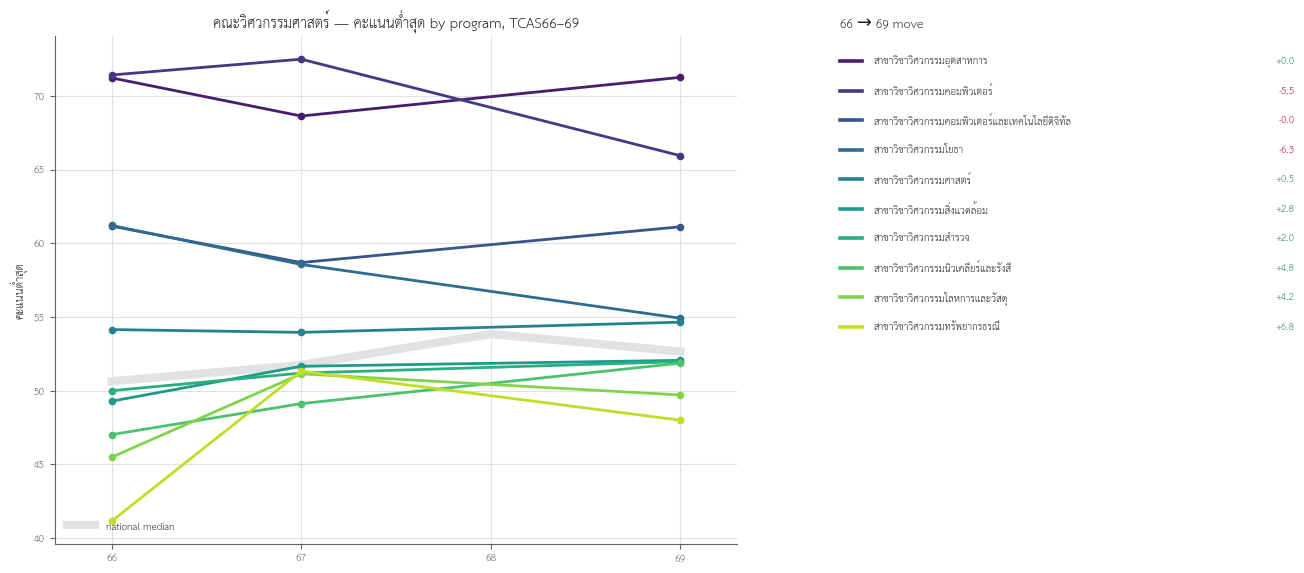

In [6]:
for faculty in ["คณะวิศวกรรมศาสตร์", "คณะอักษรศาสตร์", "คณะรัฐศาสตร์"]:
    f = viz.plot_faculty(faculty, df)
    viz.save(f, f"03_faculty_{faculty}")
display(viz.plot_faculty("คณะวิศวกรรมศาสตร์", df))

## 4. Min–max spread

The gap between the top and bottom admitted score, per program. A narrowing
spread means the admitted cohort is bunching together.

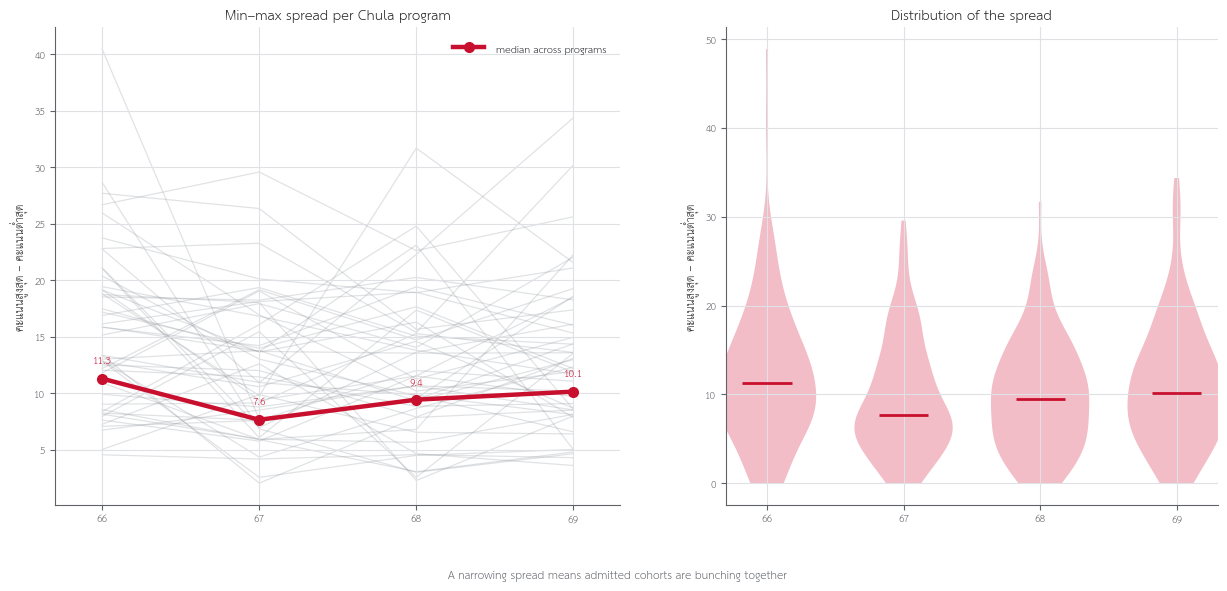

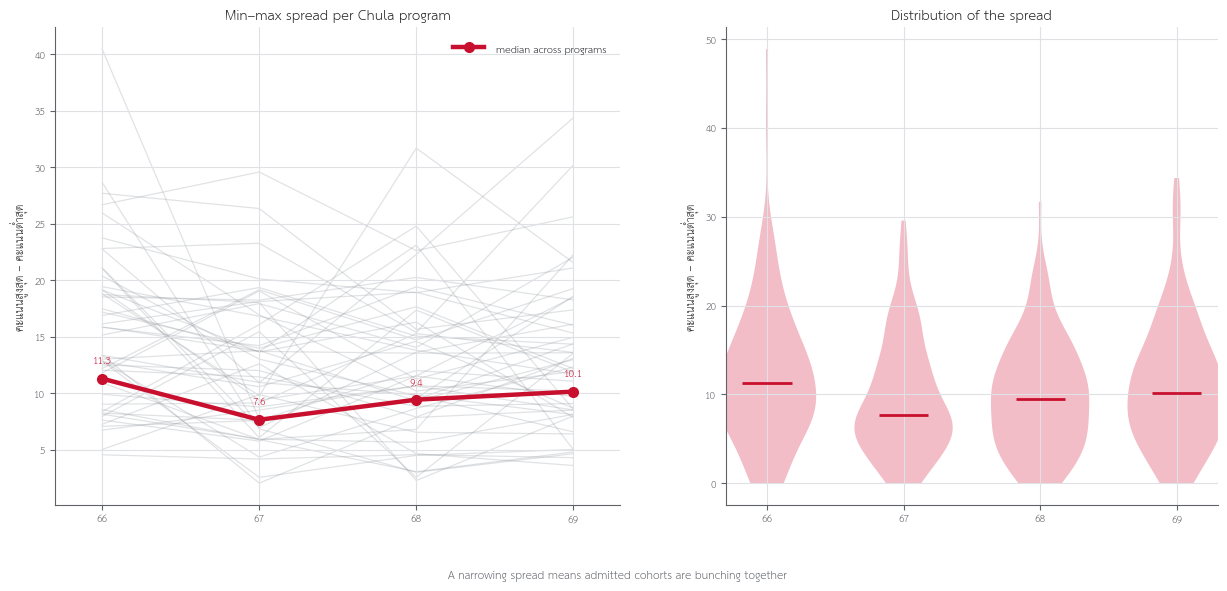

In [7]:
fig = viz.fig_min_max_spread(df)
viz.save(fig, "04_min_max_spread")
fig

In [8]:
spread = valid.assign(spread=valid["max_score"] - valid["min_score"])
spread.groupby("year")["spread"].median().round(2).to_frame("median spread")

,median spread
year,
66,11.29
67,7.65
68,9.43
69,10.14


The spread is **not** a clean narrowing: 11.29 → 7.65 → 9.43 → 10.14. It
collapses in TCAS67 and then re-widens most of the way back. Whatever happened
in 67 did not persist, so this chart does not support a "cohorts are steadily
bunching" claim.

## 5. Competition — the headline

Applications, admits, and applications per admit. Two deliberate omissions:

- **Seats (`รับ`) are not plotted.** They cannot be summed and the best
  reconstruction lands below actual admits in all four years (Trap 1).
- **The axis says "applications", not "applicants".** One student holds up to
  10 choices and can appear in up to 10 rows. This file cannot count people.

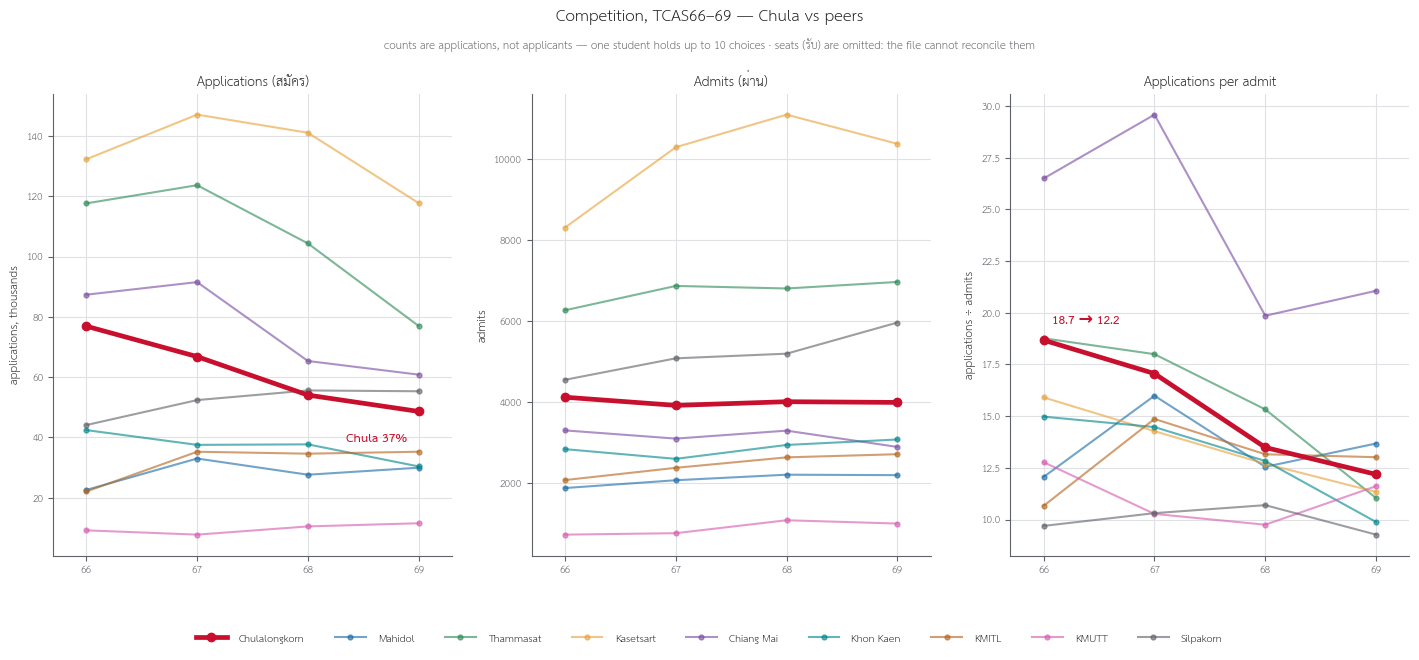

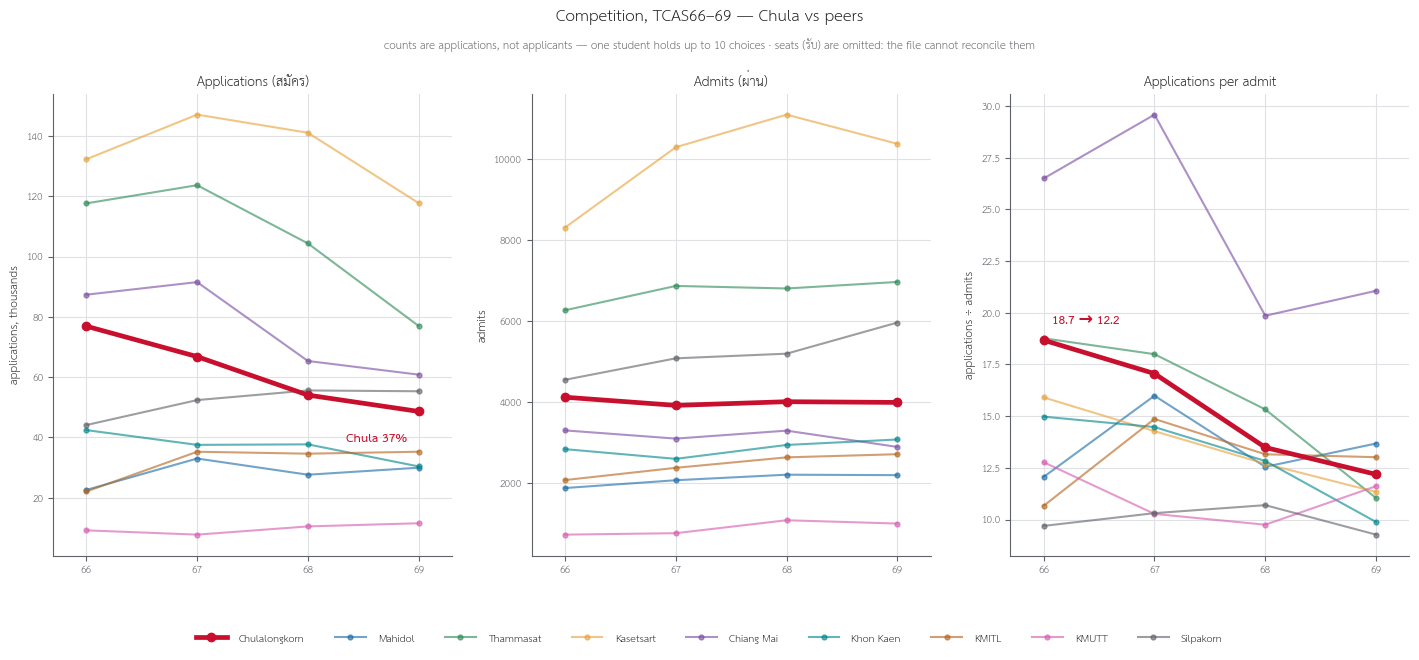

In [9]:
fig = viz.fig_competition(df)
viz.save(fig, "05_competition")
fig

In [10]:
comp = ch.groupby("year").agg(applications=("applied", "sum"), admits=("passed", "sum"))
comp["per admit"] = (comp["applications"] / comp["admits"]).round(1)
comp

,applications,admits,per admit
year,,,
66,76905.0,4118.0,18.7
67,66806.0,3916.0,17.1
68,54045.0,4007.0,13.5
69,48615.0,3989.0,12.2


Applications fell **37%** while admits stayed within 5% of flat, so
applications per admit went 18.7 → 12.2. Yet the median Chula floor did not
fall, and on percentile rank Chula sat at 77.8 → 78.0 — unchanged.

**Far fewer applications, and the bar did not move.** That tension is the
project's central finding. What this file *cannot* say is why: `สมัคร` counts
applications, so the drop is equally consistent with fewer students, or the
same students using fewer of their 10 choices.

## 6. Peer comparison — with the scale warning attached

KMITL, Chiang Mai, Thammasat and Silpakorn publish **T-Score-weighted**
composites; Chula and the rest publish raw-weighted percent. Those series are
drawn dashed with square markers. Compare their *shape* over time, never their
*level* against Chula's.

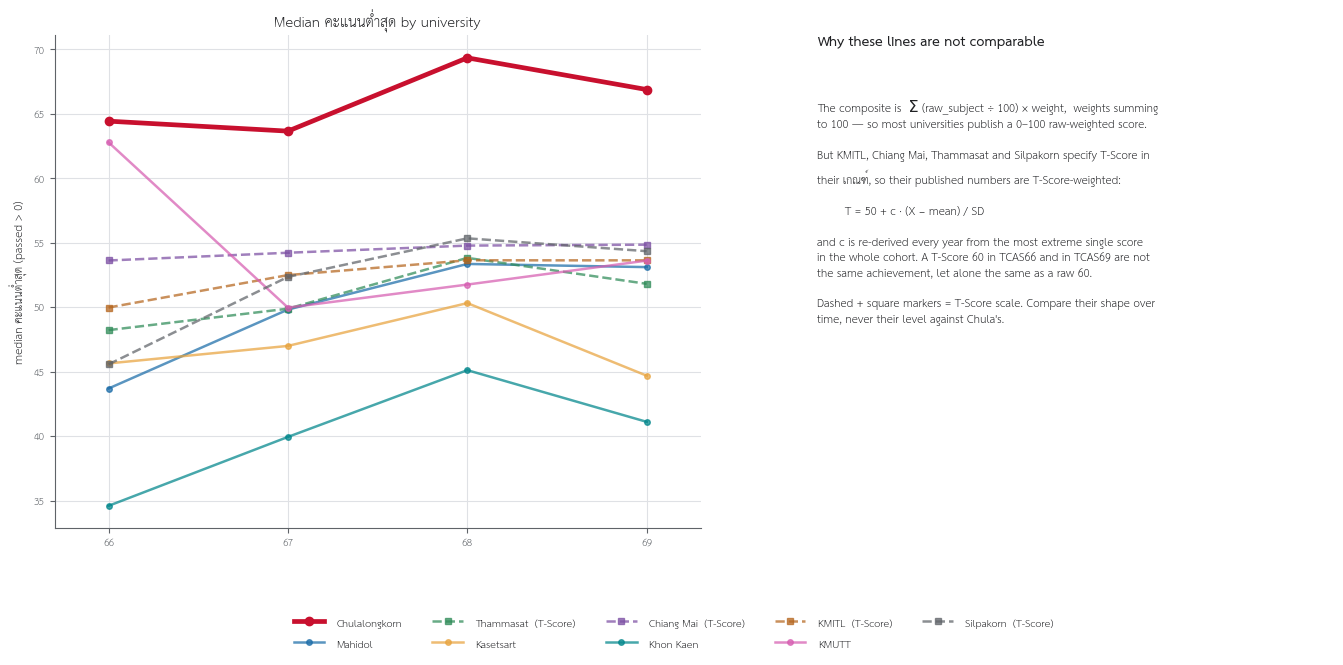

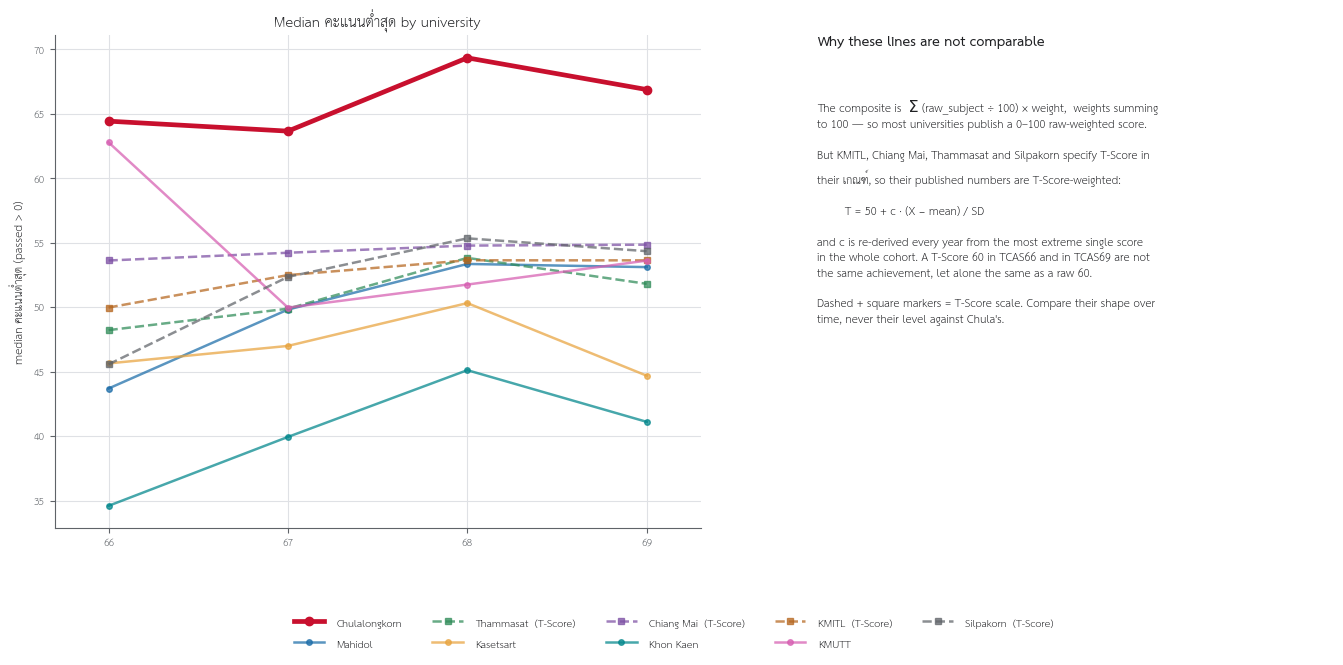

In [11]:
fig = viz.fig_peer_comparison(df)
viz.save(fig, "06_peer_comparison")
fig

## 7. Exam difficulty — why raw scores lie

Subject means and SDs by year, the published T-Score coefficient, and the one
subject that pinned it each year.

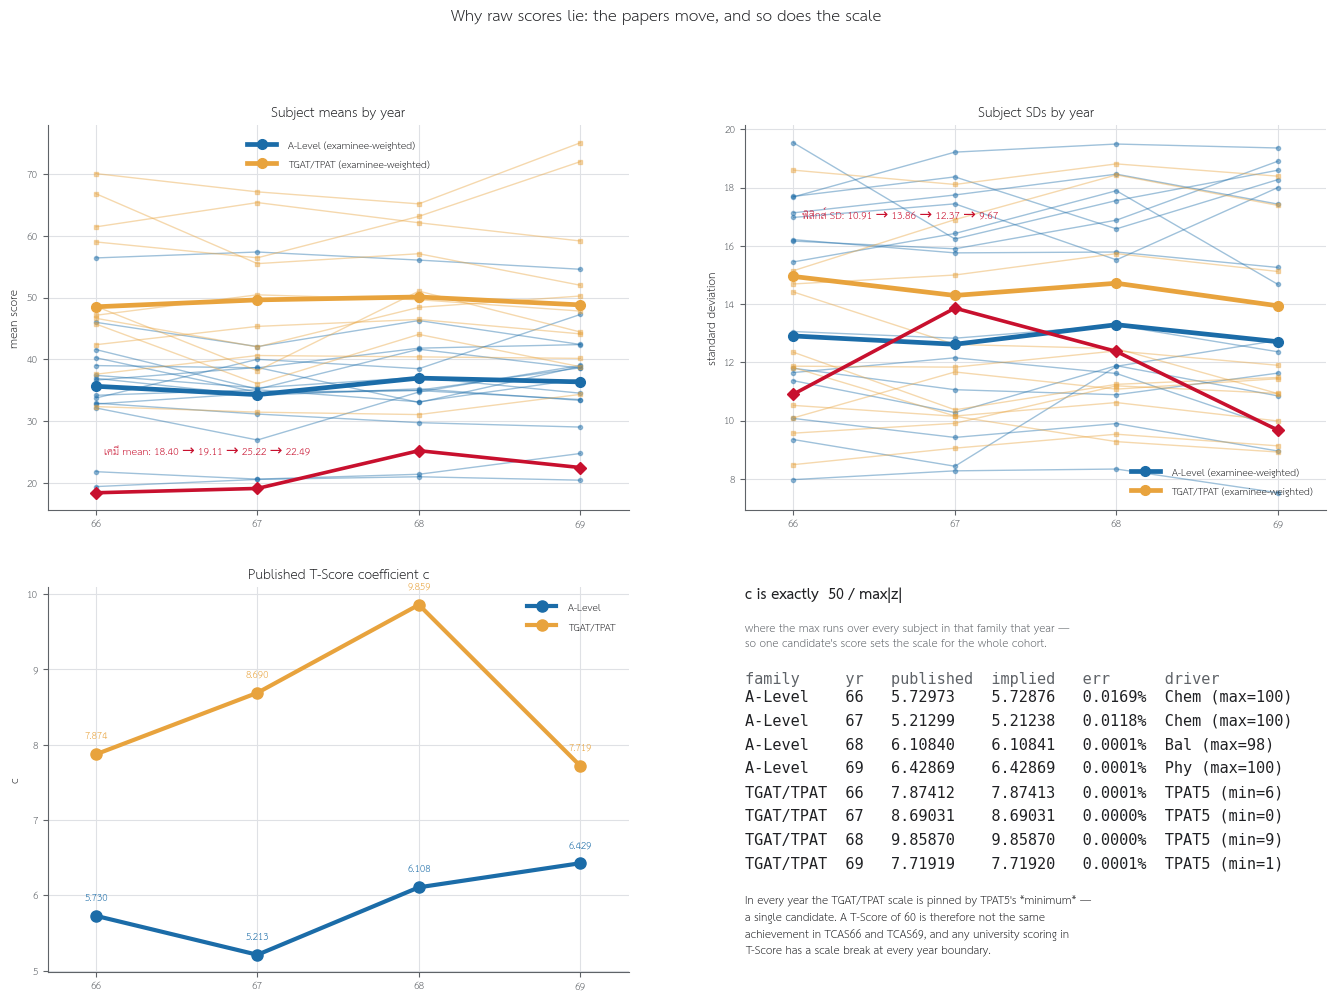

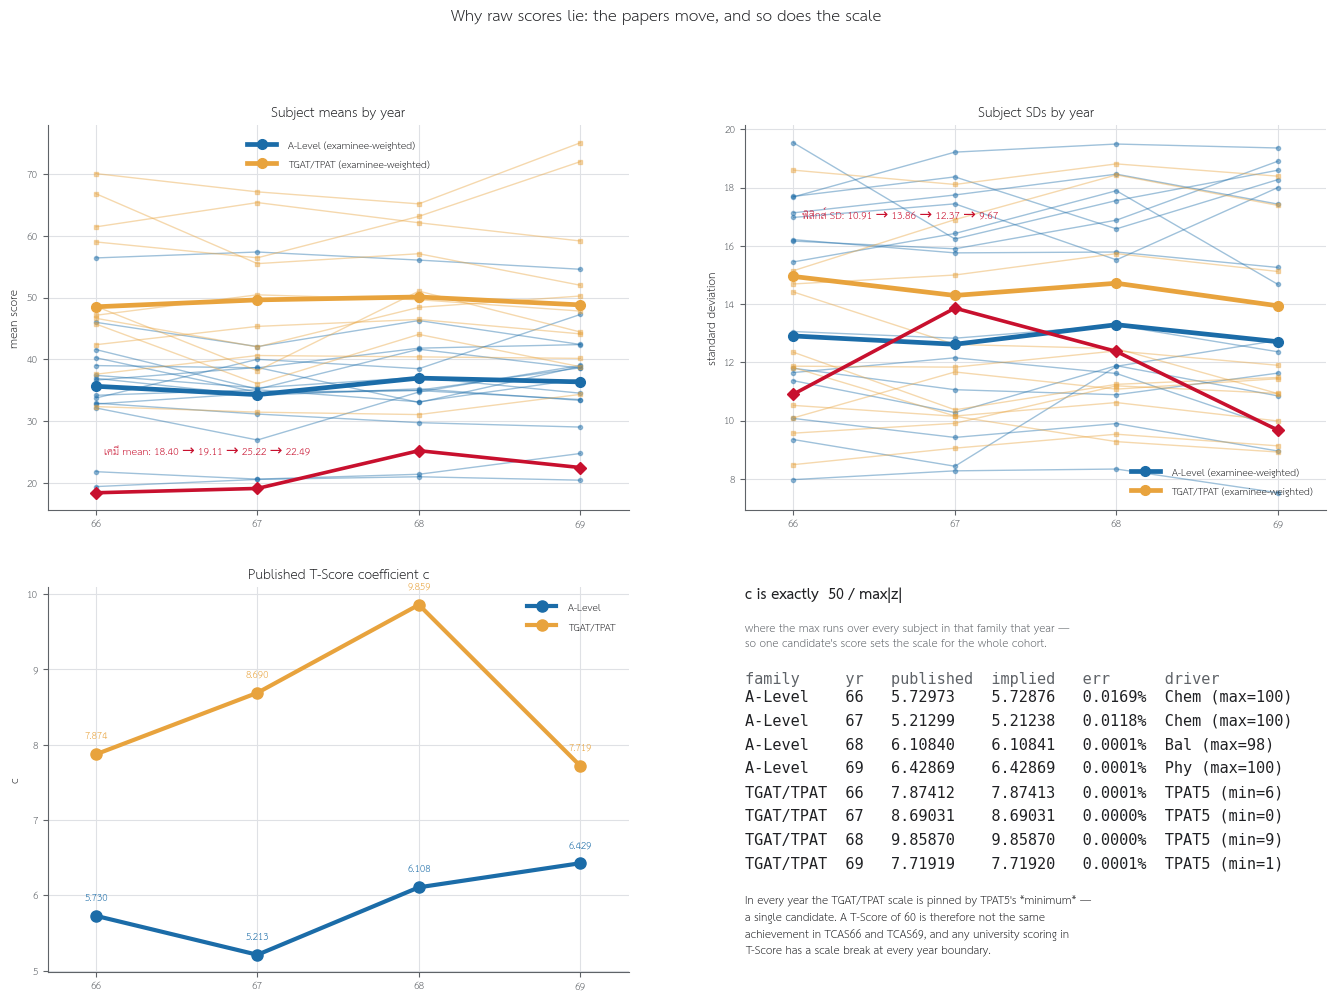

In [12]:
fig = viz.fig_exam_difficulty()
viz.save(fig, "07_exam_difficulty")
fig

In [13]:
from src.normalize import tscore_drivers, cohort_difficulty_index
tscore_drivers().round(5)

,exam_family,tcas_year,published_c,implied_c,rel_error,driver,driver_th,side,driver_value
0,A-Level,66,5.72973,5.72876,0.00017,Chem,เคมี,max,100.0
1,A-Level,67,5.21299,5.21238,0.00012,Chem,เคมี,max,100.0
2,A-Level,68,6.10840,6.10841,0.00000,Bal,ภาษาบาลี,max,98.0
3,A-Level,69,6.42869,6.42869,0.00000,Phy,ฟิสิกส์,max,100.0
4,TGAT/TPAT,66,7.87412,7.87413,0.00000,TPAT5,TPAT5 ความถนัดครุศาสตร์-ศึกษาศาสตร์,min,6.0
5,TGAT/TPAT,67,8.69031,8.69031,0.00000,TPAT5,TPAT5 ความถนัดครุศาสตร์-ศึกษาศาสตร์,min,0.0
6,TGAT/TPAT,68,9.85870,9.85870,0.00000,TPAT5,TPAT5 ความถนัดครุศาสตร์-ศึกษาศาสตร์,min,9.0
7,TGAT/TPAT,69,7.71919,7.71920,0.00000,TPAT5,TPAT5 ความถนัดครุศาสตร์-ศึกษาศาสตร์,min,1.0


`c = 50 / max|z|` reproduces all eight published coefficients to within
0.017%. The consequence is concrete: in **every** year the TGAT/TPAT scale is
pinned by TPAT5's *minimum* — one candidate's score fixes the scale for the
whole cohort. A T-Score of 60 is therefore not the same achievement in TCAS66
and TCAS69, and every T-Score university has a scale break at each year
boundary.

Chula scores raw, so it escapes that — but not paper difficulty. A-Level เคมี's
mean moved 18.40 → 19.11 → 25.22 → 22.49 and ฟิสิกส์'s SD moved 10.91 → 13.86 →
12.37 → 9.67. A raw-weighted composite inherits all of it, which is exactly why
the percentile track in section 1 exists.

In [14]:
cohort_difficulty_index().round(2)

,exam_family,tcas_year,mean_index,sd_index,n_subjects,n_examinees
0,A-Level,66,35.65,12.91,16.0,1021583.0
1,A-Level,67,34.29,12.62,16.0,1060775.0
2,A-Level,68,36.98,13.29,16.0,1108312.0
3,A-Level,69,36.36,12.71,16.0,1107301.0
4,TGAT/TPAT,66,48.52,14.95,9.0,993250.0
5,TGAT/TPAT,67,49.64,14.30,9.0,1033618.0
6,TGAT/TPAT,68,50.11,14.72,9.0,1096058.0
7,TGAT/TPAT,69,48.83,13.94,9.0,1101308.0


## 8. Double Sorting

What the second processing pass does to the floor, TCAS67–69. TCAS66 is absent
because ทปอ. ran Double Sorting that year but never published it.

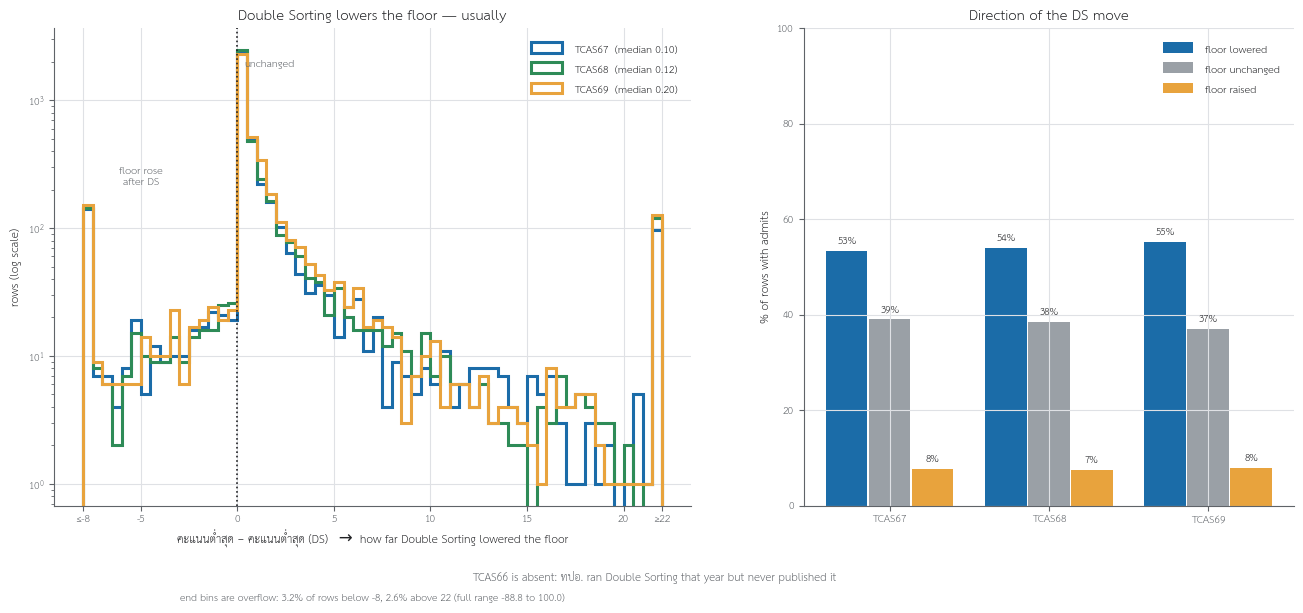

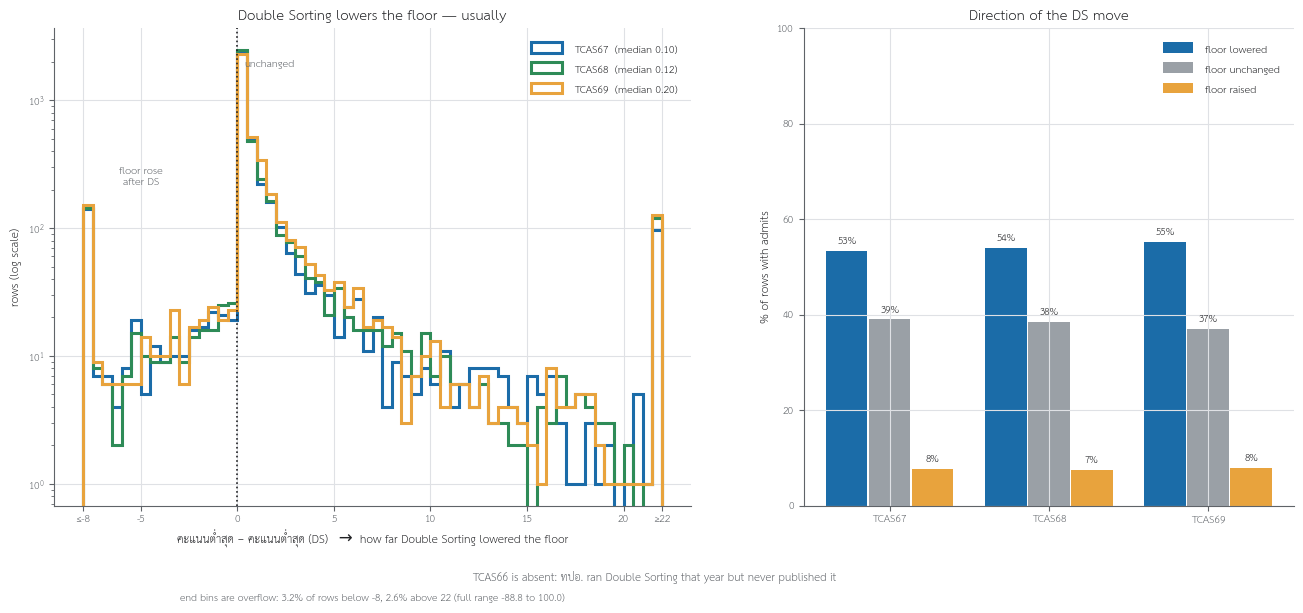

In [15]:
fig = viz.fig_ds_effect(df)
viz.save(fig, "08_ds_effect")
fig

**The spec's claim that `min_ds ≤ min` in every row is false.** DS lowers the
floor in ~54% of rows with admits, leaves ~38% untouched, and *raises* it in
~8% — 333/337/352 rows nationally in 67/68/69. The mechanism is real: when
marginal admits decline their seat the remaining floor can rise, and two TCAS68
Chula rows go from `passed == 0` to a real DS admit, which necessarily lifts
the floor off zero.

So a "DS only ever lowers the floor" assumption would be wrong roughly one time
in twelve.

In [16]:
d = df.dropna(subset=["min_score", "min_score_ds"])
d = d[d["passed"] > 0].assign(move=lambda x: x["min_score"] - x["min_score_ds"])
pd.DataFrame({
    "% lowered":   d.groupby("year")["move"].apply(lambda s: (s > 1e-9).mean() * 100),
    "% unchanged": d.groupby("year")["move"].apply(lambda s: (s.abs() <= 1e-9).mean() * 100),
    "% raised":    d.groupby("year")["move"].apply(lambda s: (s < -1e-9).mean() * 100),
}).round(1)

,% lowered,% unchanged,% raised
year,,,
67,53.3,39.0,7.7
68,54.0,38.5,7.5
69,55.3,36.9,7.8


## What these figures establish

1. **Raw scores flatter Chula.** Every faculty's percentile move is at or below
   its raw move, because the national median rose faster than Chula's floors.
   จิตวิทยา and นิติศาสตร์ flip sign entirely.
2. **คณะวิทยาศาสตร์ fell hard** — −14.6 raw, −35.5 percentile points, the only
   faculty to cross the national median.
3. **Applications fell 37% and the bar did not move.** Competition per admit
   halved; the floor did not. The file cannot say whether fewer students
   applied or the same students used fewer choices.
4. **The exam scale is pinned by single candidates.** `c = 50/max|z|`, driven
   by TPAT5's minimum in all four years — so T-Score levels are not comparable
   across years, and those universities are marked in every chart.
5. **Double Sorting is not one-directional.** It raises the floor in ~8% of
   rows with admits.

Next: `nb/05_model` (baselines before anything clever), or `reports/findings.md`
— which, per the spec's scope note, stands on its own without the model.